In [20]:
import pandas as pd
df = pd.read_csv("../data/subsidence_dataset.csv")
df

,temperature_c,humidity_pct,distance_mm_day,tilt_deg,risk_level
0,26.94,65.22,0.040,-0.831,SAFE
1,29.57,70.67,0.150,0.654,SAFE
2,24.30,48.60,2.824,0.317,WARNING
3,24.30,72.11,0.082,0.136,SAFE
4,29.74,40.00,0.089,-0.677,SAFE
...,...,...,...,...,...
1993,28.21,67.06,0.000,-0.271,SAFE
1994,24.92,78.83,2.016,1.173,WARNING
1995,22.35,50.39,0.166,-1.127,SAFE
1996,24.51,70.62,2.636,-1.226,WARNING


In [21]:
df.columns

Index(['temperature_c', 'humidity_pct', 'distance_mm_day', 'tilt_deg',
       'risk_level'],
      dtype='object')

In [22]:
df.dtypes

temperature_c      float64
humidity_pct       float64
distance_mm_day    float64
tilt_deg           float64
risk_level          object
dtype: object

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [24]:
feature_cols = ['temperature_c', 'humidity_pct', 'distance_mm_day', 'tilt_deg']
label_col = 'risk_level'

In [25]:
df[label_col], classes = pd.factorize(df[label_col])
dict(enumerate(classes))

{0: 'SAFE', 1: 'WARNING', 2: 'DANGER'}

In [26]:
X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
y = torch.tensor(df[label_col].values, dtype=torch.long)

In [27]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [28]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model = Net()

In [29]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.0472
Epoch 2, Loss: 0.0455
Epoch 3, Loss: 0.0424
Epoch 4, Loss: 0.0416
Epoch 5, Loss: 0.0408
Epoch 6, Loss: 0.0409
Epoch 7, Loss: 0.0418
Epoch 8, Loss: 0.0374
Epoch 9, Loss: 0.0363
Epoch 10, Loss: 0.0354
Epoch 11, Loss: 0.0384
Epoch 12, Loss: 0.0332
Epoch 13, Loss: 0.0366
Epoch 14, Loss: 0.0392
Epoch 15, Loss: 0.0341
Epoch 16, Loss: 0.0331
Epoch 17, Loss: 0.0330
Epoch 18, Loss: 0.0330
Epoch 19, Loss: 0.0312
Epoch 20, Loss: 0.0330


In [33]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in loader:
        outputs = model(xb)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9935


In [35]:
torch.save(model.state_dict(), "sim_model.pt")

In [36]:
import os
print(f"Size: {os.path.getsize('model.pt') / 1024:.2f} KB")

Size: 4.18 KB


<Axes: >

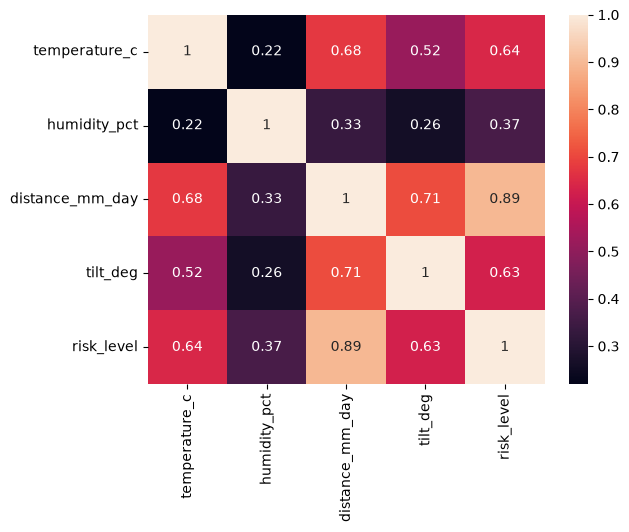

In [38]:
import seaborn as sns
sns.heatmap(df.corr(), annot=True)